# Treatment Effect & Genotype Modulation Analysis: PBS vs Lecanemab

This notebook quantifies Aβ plaque burden, size, and distribution comparing Lecanemab vs PBS treatment groups, and evaluates how ApoE genotype (ApoE3 vs ApoE4) modulates the treatment effect.

## Outline
1. Setup & data loading  
2. Subject-level metrics (count, size, volume)  
3. Descriptive statistics & boxplots  
4. Violin plots of plaque-size distributions  
5. Two-way ANOVA (treatment × genotype) for each metric  
6. Interaction plots  
7. Post-hoc pairwise comparisons (Tukey HSD)  
8. Genotype-stratified analysis  
9. Summary of findings  

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore", category=FutureWarning)

# ── aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
TREAT_ORDER   = ["PBS", "Lecanemab"]
TREAT_PALETTE = {"PBS": "#4C72B0", "Lecanemab": "#DD8452"}
GENO_ORDER    = ["ApoE3", "ApoE4"]
GENO_PALETTE  = {"ApoE3": "#55A868", "ApoE4": "#C44E52"}
DATASET_NAMES = ["early", "late"]


## 1  Setup & data loading

In [2]:
def compute_subject_metrics(plaque_df):
    """Aggregate plaque-level data to one row per subject."""
    grp = plaque_df.groupby(["subject", "treatment", "genotype", "sex"], observed=True)

    metrics = grp.agg(
        plaque_count     = ("nvoxels",       "size"),
        total_vol_ml     = ("plaque_vol_ml",  "sum"),
        mean_vol_ml      = ("plaque_vol_ml",  "mean"),
        median_vol_ml    = ("plaque_vol_ml",  "median"),
        mean_diam_um     = ("equiv_diam_um",  "mean"),
        median_diam_um   = ("equiv_diam_um",  "median"),
        total_vol_um3    = ("plaque_vol_um3", "sum"),
    ).reset_index()

    # log-transform heavily skewed outcomes (used for modelling)
    for col in ["plaque_count", "total_vol_ml", "mean_vol_ml", "median_vol_ml",
                "mean_diam_um", "median_diam_um", "total_vol_um3"]:
        metrics[f"log_{col}"] = np.log(metrics[col])

    return metrics


In [3]:
def boxstrip(ax, data, x, y, hue=None, order=None, hue_order=None, palette=None,
             ylabel=None, yscale="linear"):
    """Paired boxplot + stripplot helper."""
    sns.boxplot(data=data, x=x, y=y, hue=hue,
                order=order, hue_order=hue_order, palette=palette,
                fill=False, linewidth=1.2, fliersize=0, ax=ax)
    sns.stripplot(data=data, x=x, y=y, hue=hue,
                  order=order, hue_order=hue_order, palette=palette,
                  dodge=True, alpha=0.7, size=6, jitter=True, ax=ax)
    if yscale != "linear":
        ax.set_yscale(yscale)
    if ylabel:
        ax.set_ylabel(ylabel)
    # keep only one legend
    handles, labels = ax.get_legend_handles_labels()
    n = len(hue_order) if hue_order else 2
    ax.legend(handles[:n], labels[:n], title=hue, fontsize=9)


In [4]:
def run_twoway_anova(data, outcome, formula_extra=""):
    """
    Two-way OLS ANOVA: outcome ~ C(treatment) * C(genotype)
    Falls back to one-way (treatment only) when only one genotype is present.
    Returns the type-II ANOVA table.
    """
    n_geno = data["genotype"].nunique()
    if n_geno > 1:
        formula = f"{outcome} ~ C(treatment) * C(genotype)" + formula_extra
    else:
        formula = f"{outcome} ~ C(treatment)" + formula_extra
    model   = ols(formula, data=data).fit()
    table   = anova_lm(model, typ=2)
    return table


In [5]:
def interaction_plot_ax(ax, data, outcome, ylabel, yscale="linear"):
    """Mean ± SEM interaction plot (treatment on x, genotype as lines)."""
    agg = (
        data.groupby(["treatment", "genotype"], observed=True)[outcome]
        .agg(["mean", "sem"])
        .reset_index()
    )
    for geno, grp in agg.groupby("genotype", observed=True):
        color = GENO_PALETTE[geno]
        ax.plot(grp["treatment"].astype(str), grp["mean"],
                marker="o", linewidth=2, color=color, label=geno)
        ax.errorbar(grp["treatment"].astype(str), grp["mean"],
                    yerr=grp["sem"], fmt="none", color=color, capsize=4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Treatment")
    if yscale != "linear":
        ax.set_yscale(yscale)
    ax.legend(title="Genotype", fontsize=9)


In [6]:
def tukey_posthoc(data, outcome, group_col="treatment_genotype"):
    """Run Tukey HSD across all treatment × genotype combinations."""
    d = data.copy()
    d["group"] = d["treatment"].astype(str) + " | " + d["genotype"].astype(str)
    result = pairwise_tukeyhsd(d[outcome], d["group"], alpha=0.05)
    return result



=== Dataset: early ===
Plaque instances after size filter: 491,861
   treatment genotype  n_subjects
0        PBS    ApoE4           3
1  Lecanemab    ApoE4           3


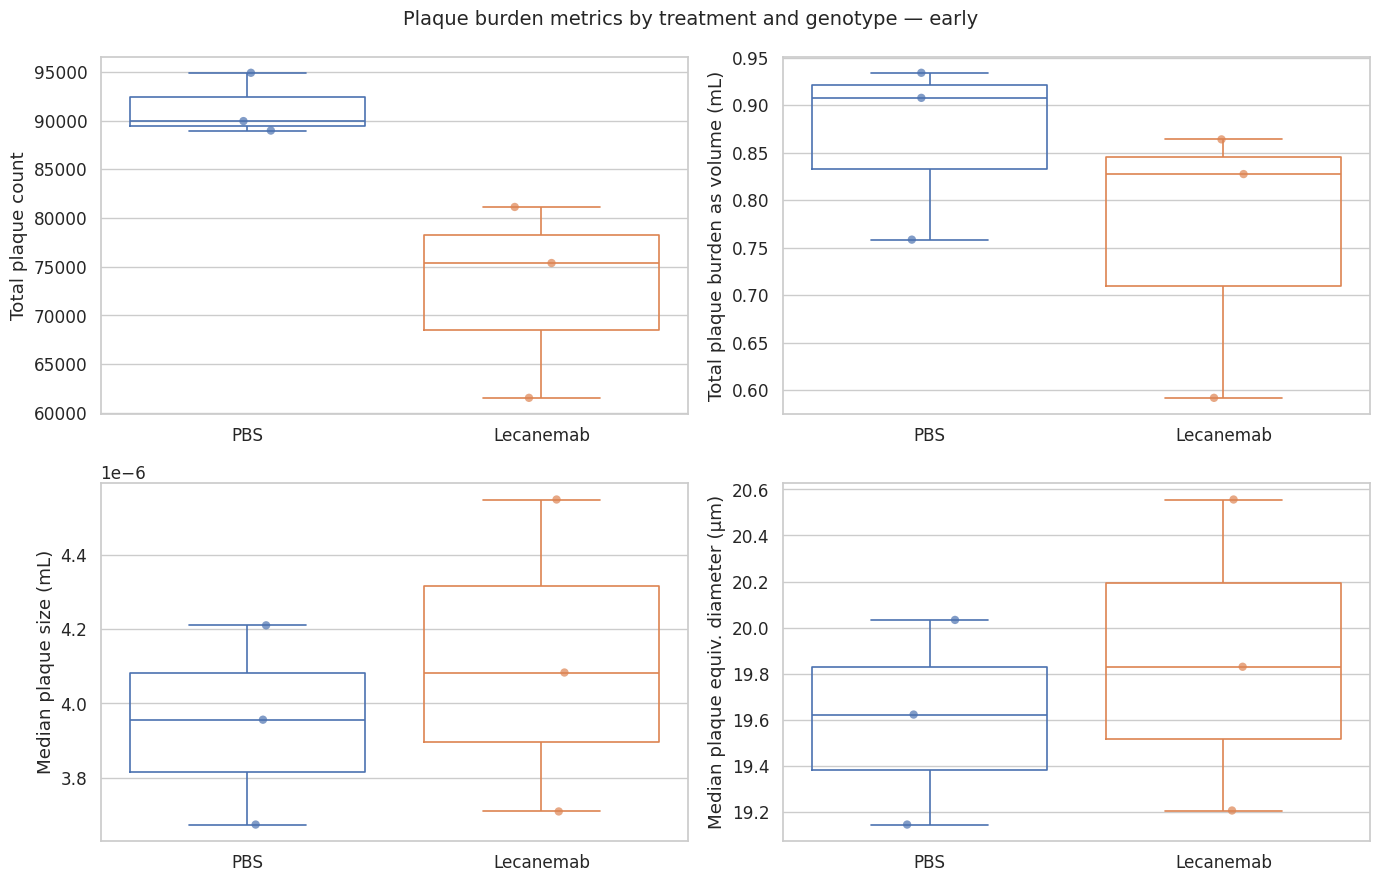

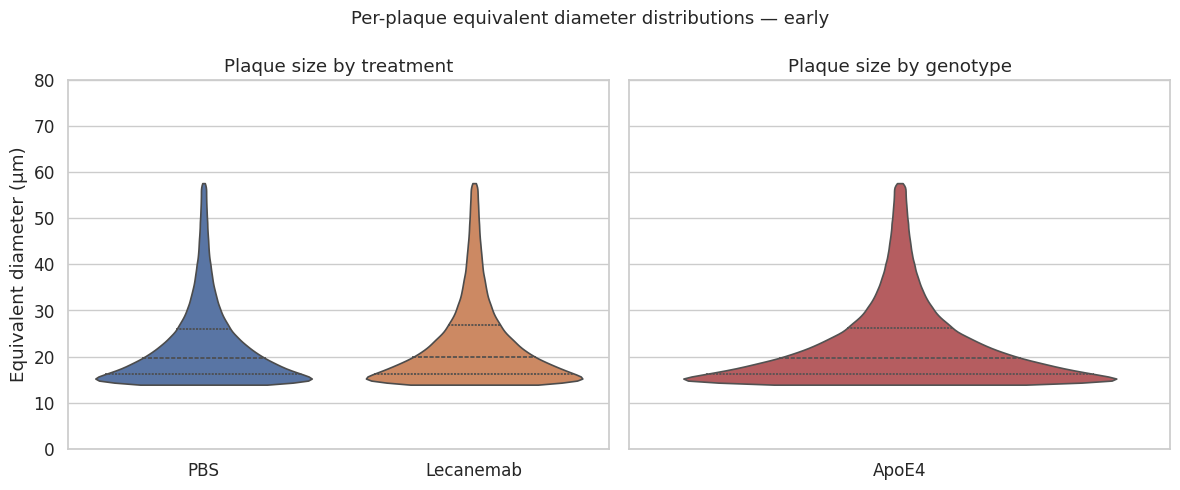


Two-way ANOVA summary (type II SS) — early
             Outcome         Term        F  p-value sig
   log(Plaque count) C(treatment) 7.578110 0.051225    
   log(Plaque count)     Residual      NaN      NaN    
   log(Total volume) C(treatment) 1.049912 0.363447    
   log(Total volume)     Residual      NaN      NaN    
    log(Mean volume) C(treatment) 1.516941 0.285540    
    log(Mean volume)     Residual      NaN      NaN    
  log(Median volume) C(treatment) 0.310719 0.606958    
  log(Median volume)     Residual      NaN      NaN    
  Mean diameter (µm) C(treatment) 0.948734 0.385196    
  Mean diameter (µm)     Residual      NaN      NaN    
Median diameter (µm) C(treatment) 0.319046 0.602354    
Median diameter (µm)     Residual      NaN      NaN    

Tukey HSD for log(Plaque count) — early:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
      group1         group2   meandiff p-adj  lower  upper  reject
----------------------------------------------------

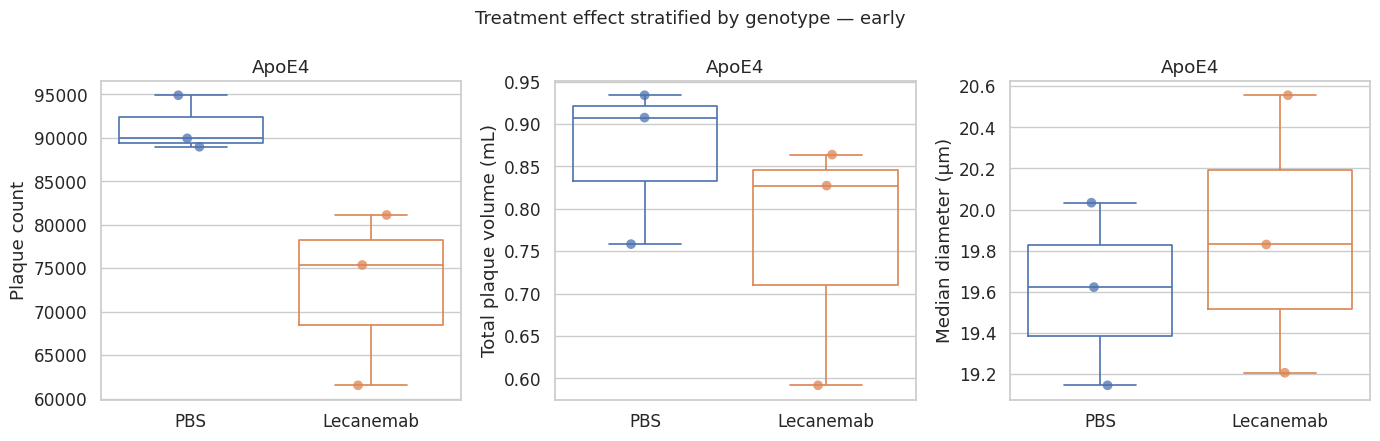

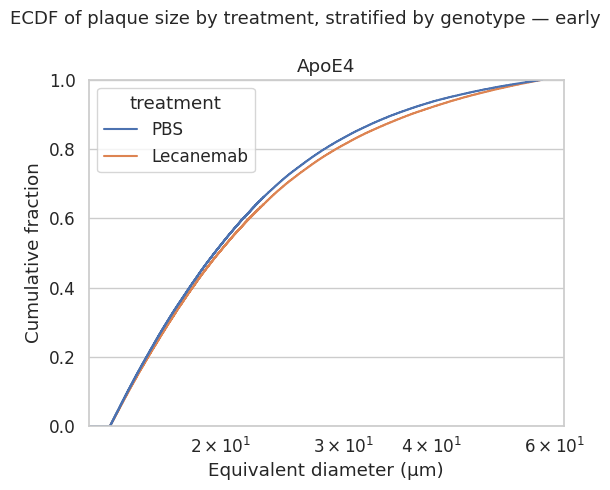

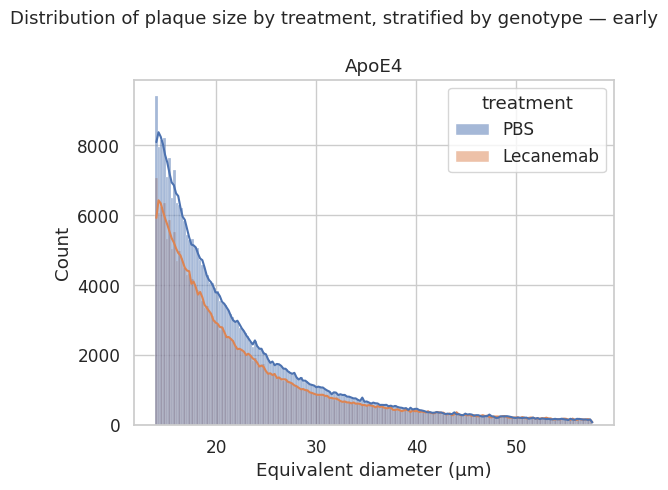


=== Dataset: late ===
Plaque instances after size filter: 665,630
   treatment genotype  n_subjects
0        PBS    ApoE3           3
1        PBS    ApoE4           2
2  Lecanemab    ApoE3           3
3  Lecanemab    ApoE4           2


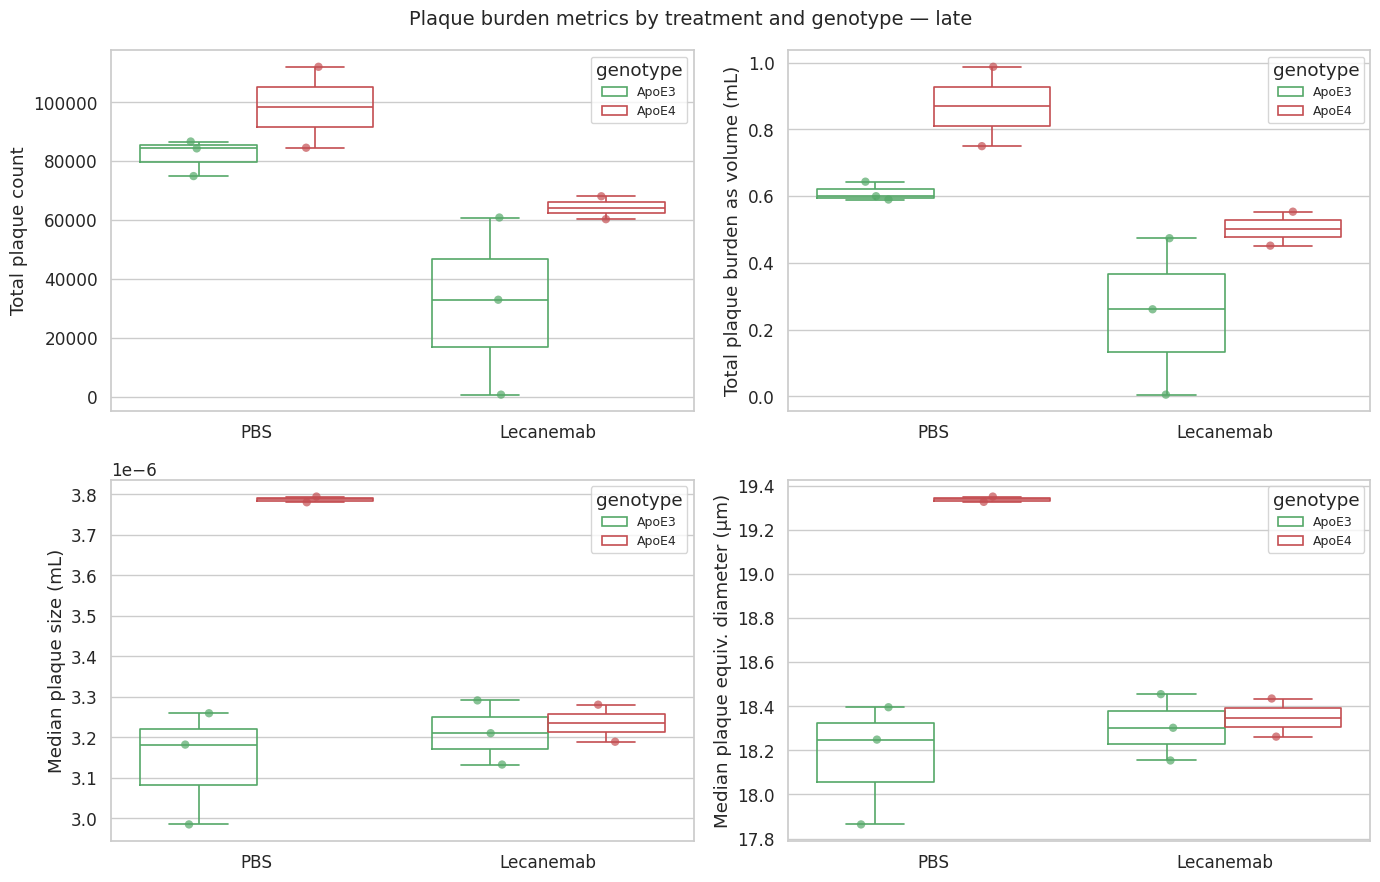

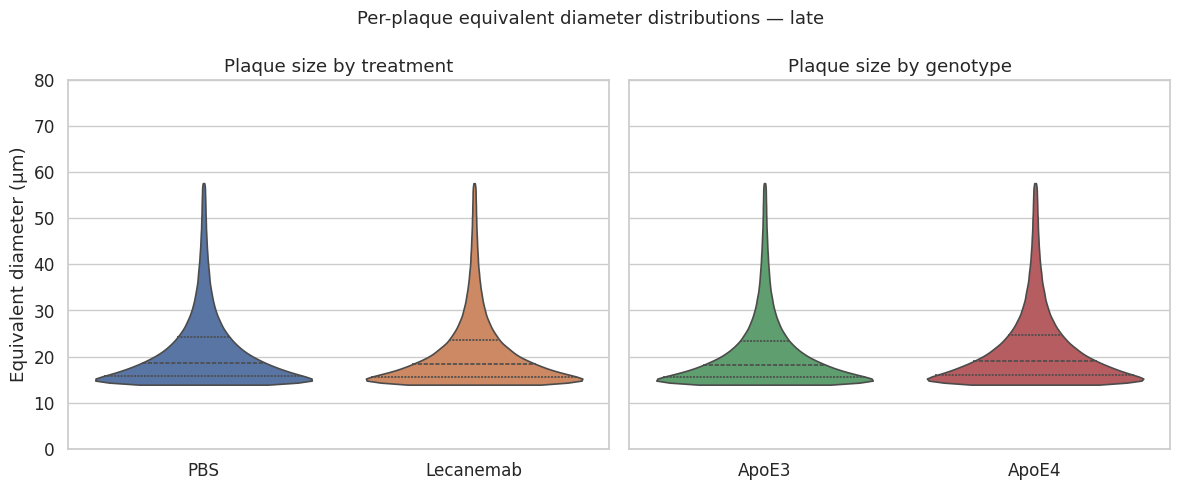


Two-way ANOVA summary (type II SS) — late
             Outcome                     Term         F  p-value sig
   log(Plaque count)             C(treatment)  2.385650 0.173405    
   log(Plaque count)              C(genotype)  1.133752 0.327938    
   log(Plaque count) C(treatment):C(genotype)  0.756492 0.417860    
   log(Plaque count)                 Residual       NaN      NaN    
   log(Total volume)             C(treatment)  2.412057 0.171394    
   log(Total volume)              C(genotype)  1.317992 0.294657    
   log(Total volume) C(treatment):C(genotype)  0.595125 0.469726    
   log(Total volume)                 Residual       NaN      NaN    
    log(Mean volume)             C(treatment)  1.504612 0.265911    
    log(Mean volume)              C(genotype)  9.096260 0.023518   *
    log(Mean volume) C(treatment):C(genotype)  4.846945 0.069950    
    log(Mean volume)                 Residual       NaN      NaN    
  log(Median volume)             C(treatment)  6.448120 0.04

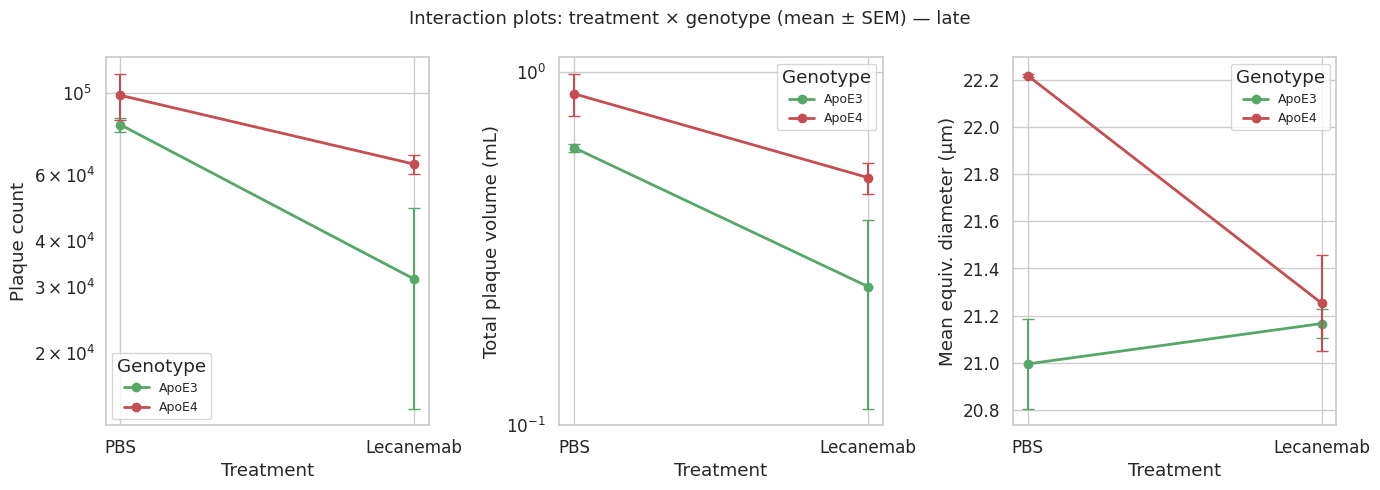


Tukey HSD for log(Plaque count) — late:
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
Lecanemab | ApoE3 Lecanemab | ApoE4   1.7222 0.5591 -2.6361 6.0806  False
Lecanemab | ApoE3       PBS | ApoE3   1.9667 0.3795 -1.9315  5.865  False
Lecanemab | ApoE3       PBS | ApoE4   2.1403 0.3993  -2.218 6.4987  False
Lecanemab | ApoE4       PBS | ApoE3   0.2445 0.9971 -4.1139 4.6028  False
Lecanemab | ApoE4       PBS | ApoE4   0.4181 0.9894 -4.3562 5.1924  False
      PBS | ApoE3       PBS | ApoE4   0.1736  0.999 -4.1847  4.532  False
-------------------------------------------------------------------------
Significant Tukey contrasts: 10

Mann-Whitney U: PBS vs Lecanemab, stratified by genotype — late
genotype            outcome   PBS_median  Lecanemab_median  fold_change_LvP   U  p_value  sig
   ApoE3       Plaque count 

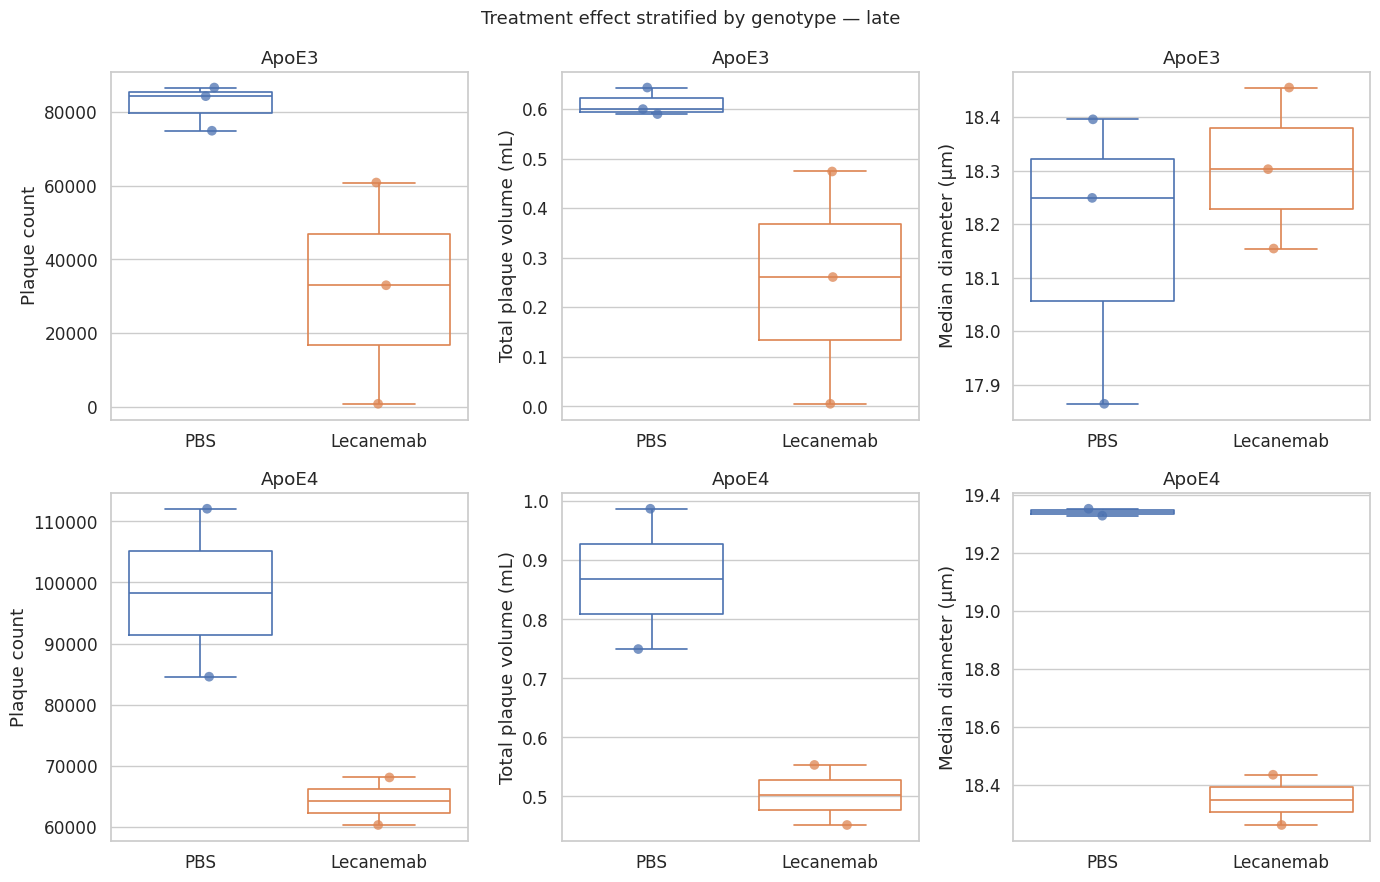

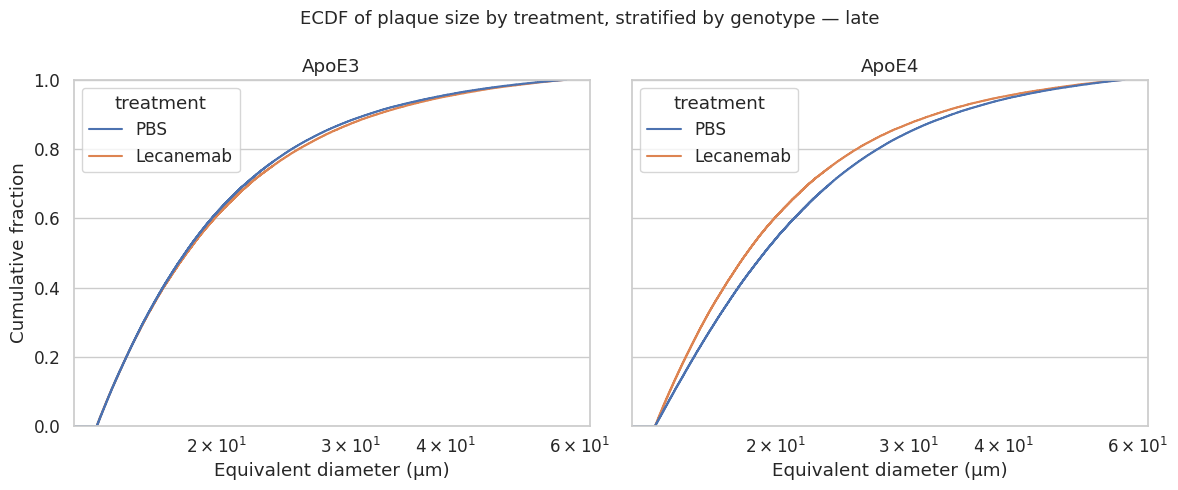

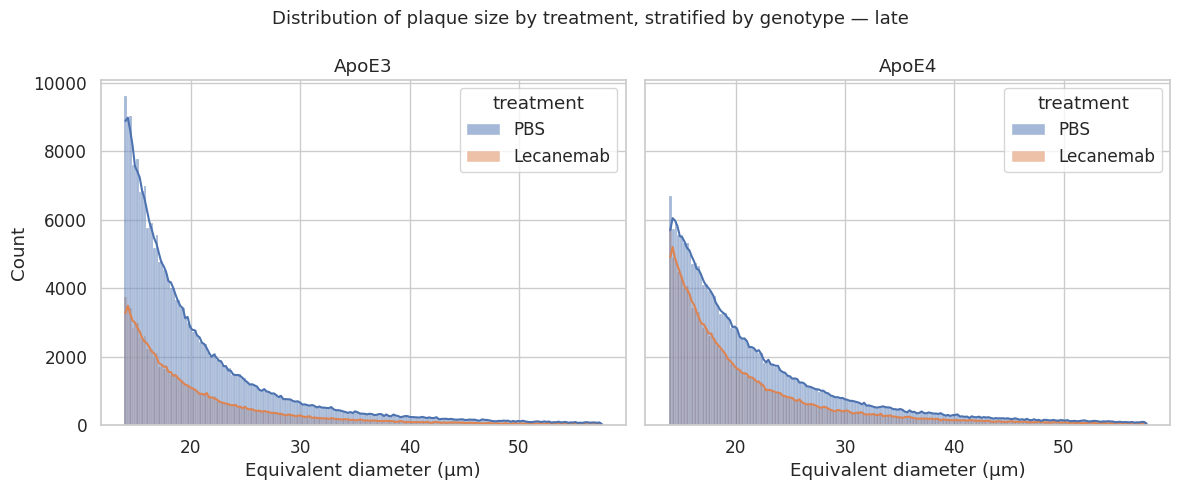

In [7]:
def run_treatment_analysis(name, df):
    """Run all treatment effect analysis for one dataset."""
    df = df.loc[df["plaque_vol_ml"] <= VOL_THRESH_ML].copy()
    df["treatment"] = pd.Categorical(df["treatment"], categories=TREAT_ORDER, ordered=True)
    # Determine which genotypes are actually present in this dataset
    geno_present = [g for g in GENO_ORDER if (df["genotype"] == g).any()]
    df["genotype"] = pd.Categorical(df["genotype"], categories=geno_present, ordered=True)
    geno_palette  = {g: GENO_PALETTE[g] for g in geno_present}
    multi_geno = len(geno_present) > 1

    print(f"\n=== Dataset: {name} ===")
    print(f"Plaque instances after size filter: {len(df):,}")
    print(df.groupby(["treatment", "genotype"])["subject"].nunique()
          .rename("n_subjects").reset_index())

    subj = compute_subject_metrics(df)
    subj["genotype"] = pd.Categorical(subj["genotype"], categories=geno_present, ordered=True)

    # ── boxplots ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    metrics_to_plot = [
        ("plaque_count",   "Total plaque count",                "linear"),
        ("total_vol_ml",   "Total plaque burden as volume (mL)","linear"),
        ("median_vol_ml",  "Median plaque size (mL)",           "linear"),
        ("median_diam_um", "Median plaque equiv. diameter (\u00b5m)","linear"),
    ]
    hue_kw = dict(hue="genotype", hue_order=geno_present, palette=geno_palette) if multi_geno else {}
    for ax, (col, label, yscale) in zip(axes.flat, metrics_to_plot):
        if multi_geno:
            boxstrip(ax, subj, x="treatment", y=col, hue="genotype",
                     order=TREAT_ORDER, hue_order=geno_present, palette=geno_palette,
                     ylabel=label, yscale=yscale)
        else:
            sns.boxplot(data=subj, x="treatment", y=col, order=TREAT_ORDER,
                        palette=TREAT_PALETTE, fill=False, linewidth=1.2, fliersize=0, ax=ax)
            sns.stripplot(data=subj, x="treatment", y=col, order=TREAT_ORDER,
                          palette=TREAT_PALETTE, alpha=0.7, size=6, jitter=True, ax=ax)
            ax.set_ylabel(label)
        ax.set_xlabel("")
    fig.suptitle(f"Plaque burden metrics by treatment and genotype \u2014 {name}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_boxplots_treatment_genotype.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── violin plots ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, (hue_col, hue_order, palette) in zip(
        axes,
        [
            ("treatment", TREAT_ORDER,  TREAT_PALETTE),
            ("genotype",  geno_present, geno_palette),
        ],
    ):
        sns.violinplot(
            data=df, x=hue_col, y="equiv_diam_um", order=hue_order, palette=palette,
            inner="quartile", cut=0, linewidth=1.2, ax=ax,
        )
        ax.set_ylabel("Equivalent diameter (\u00b5m)")
        ax.set_xlabel("")
        ax.set_ylim(0, 80)
    axes[0].set_title("Plaque size by treatment")
    axes[1].set_title("Plaque size by genotype")
    fig.suptitle(f"Per-plaque equivalent diameter distributions \u2014 {name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_violin_plaque_size.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── two-way ANOVA ─────────────────────────────────────────────────────
    outcomes = {
        "log_plaque_count":  "log(Plaque count)",
        "log_total_vol_ml":  "log(Total volume)",
        "log_mean_vol_ml":   "log(Mean volume)",
        "log_median_vol_ml": "log(Median volume)",
        "mean_diam_um":      "Mean diameter (\u00b5m)",
        "median_diam_um":    "Median diameter (\u00b5m)",
    }
    anova_results = {}
    summary_rows  = []
    for col, label in outcomes.items():
        tbl = run_twoway_anova(subj, col)
        anova_results[col] = tbl
        for term, row in tbl.iterrows():
            summary_rows.append({
                "Outcome": label, "Term": term,
                "F": row.get("F", np.nan), "p-value": row.get("PR(>F)", np.nan),
            })
    anova_summary = pd.DataFrame(summary_rows)
    anova_summary["sig"] = anova_summary["p-value"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    )
    print(f"\nTwo-way ANOVA summary (type II SS) \u2014 {name}")
    print("=" * 80)
    print(anova_summary.to_string(index=False))

    # ── interaction plots (only meaningful with multiple genotypes) ───────
    int_metrics = [
        ("plaque_count",  "Plaque count",              "log"),
        ("total_vol_ml",  "Total plaque volume (mL)",  "log"),
        ("mean_diam_um",  "Mean equiv. diameter (\u00b5m)", "linear"),
    ]
    if multi_geno:
        fig, axes = plt.subplots(1, 3, figsize=(14, 5))
        for ax, (col, label, yscale) in zip(axes, int_metrics):
            interaction_plot_ax(ax, subj, col, label, yscale)
        fig.suptitle(f"Interaction plots: treatment \u00d7 genotype (mean \u00b1 SEM) \u2014 {name}", fontsize=13)
        plt.tight_layout()
        plt.savefig(f"fig_{name}_interaction_plots.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ── Tukey HSD ─────────────────────────────────────────────────────────
    posthoc_results = {}
    for col, label in outcomes.items():
        posthoc_results[col] = tukey_posthoc(subj, col)
    print(f"\nTukey HSD for log(Plaque count) \u2014 {name}:")
    print(posthoc_results["log_plaque_count"].summary())

    def tukey_to_df(res, label):
        d = res.summary().data[1:]
        cols = res.summary().data[0]
        df_t = pd.DataFrame(d, columns=cols)
        df_t["outcome"] = label
        return df_t

    frames = [tukey_to_df(posthoc_results[c], lbl) for c, lbl in outcomes.items()]
    posthoc_df = pd.concat(frames, ignore_index=True)
    sig_contrasts = posthoc_df[posthoc_df["reject"].astype(str) == "True"]
    print(f"Significant Tukey contrasts: {len(sig_contrasts)}")

    # ── stratified analysis ───────────────────────────────────────────────
    strat_rows = []
    for geno in geno_present:
        g   = subj[subj["genotype"] == geno]
        pbs = g[g["treatment"] == "PBS"]
        lec = g[g["treatment"] == "Lecanemab"]
        for col, label in [
            ("plaque_count",  "Plaque count"),
            ("total_vol_ml",  "Total volume (mL)"),
            ("mean_diam_um",  "Mean diameter (\u00b5m)"),
        ]:
            if len(pbs) == 0 or len(lec) == 0:
                continue
            stat, p = stats.mannwhitneyu(
                pbs[col].values, lec[col].values, alternative="two-sided"
            )
            fc = lec[col].median() / pbs[col].median()
            strat_rows.append(dict(
                genotype=geno, outcome=label,
                PBS_median=pbs[col].median(), Lecanemab_median=lec[col].median(),
                fold_change_LvP=fc, U=stat, p_value=p,
            ))

    if strat_rows:
        strat_df = pd.DataFrame(strat_rows)
        strat_df["sig"] = strat_df["p_value"].apply(
            lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
        )
        print(f"\nMann-Whitney U: PBS vs Lecanemab, stratified by genotype \u2014 {name}")
        print(strat_df.to_string(index=False))

    # ── genotype-stratified boxplots ──────────────────────────────────────
    n_geno = len(geno_present)
    fig, axes = plt.subplots(n_geno, 3, figsize=(14, 4.5 * n_geno), squeeze=False)
    for row_idx, geno in enumerate(geno_present):
        g = subj[subj["genotype"] == geno]
        for ax, (col, label, yscale) in zip(
            axes[row_idx],
            [
                ("plaque_count",   "Plaque count",             "linear"),
                ("total_vol_ml",   "Total plaque volume (mL)", "linear"),
                ("median_diam_um", "Median diameter (\u00b5m)",     "linear"),
            ],
        ):
            sns.boxplot(
                data=g, x="treatment", y=col,
                order=TREAT_ORDER, palette=TREAT_PALETTE,
                fill=False, linewidth=1.2, fliersize=0, ax=ax,
            )
            sns.stripplot(
                data=g, x="treatment", y=col,
                order=TREAT_ORDER, palette=TREAT_PALETTE,
                alpha=0.75, size=7, jitter=True, ax=ax,
            )
            if yscale != "linear":
                ax.set_yscale(yscale)
            ax.set_ylabel(label)
            ax.set_xlabel("")
            ax.set_title(geno)
    fig.suptitle(f"Treatment effect stratified by genotype \u2014 {name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_stratified_by_genotype.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── ECDF of plaque size ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_geno, figsize=(6 * n_geno, 5), sharey=True, squeeze=False)
    axes = axes[0]
    for ax, geno in zip(axes, geno_present):
        g = df[df["genotype"] == geno]
        sns.ecdfplot(
            data=g, x="equiv_diam_um", hue="treatment",
            hue_order=TREAT_ORDER, palette=TREAT_PALETTE, ax=ax,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Equivalent diameter (\u00b5m)")
        ax.set_ylabel("Cumulative fraction")
        ax.set_title(geno)
    fig.suptitle(f"ECDF of plaque size by treatment, stratified by genotype \u2014 {name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_ecdf_size_by_genotype.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── size distribution plot ────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_geno, figsize=(6 * n_geno, 5), sharey=True, squeeze=False)
    axes = axes[0]
    for ax, geno in zip(axes, geno_present):
        g = df[df["genotype"] == geno]
        sns.histplot(
            data=g, x="equiv_diam_um", hue="treatment",
            kde=True, kde_kws={"clip": (14, 100), "cut": 0, "bw_adjust": 0.1},
            hue_order=TREAT_ORDER, palette=TREAT_PALETTE, ax=ax,
        )
        ax.set_xscale("linear")
        ax.set_xlabel("Equivalent diameter (\u00b5m)")
        ax.set_ylabel("Count")
        ax.set_title(geno)
    fig.suptitle(f"Distribution of plaque size by treatment, stratified by genotype \u2014 {name}",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_size_distribution_by_genotype.png", dpi=150, bbox_inches="tight")
    plt.show()


VOL_THRESH_ML = 1e-4
for name in DATASET_NAMES:
    df_raw = pd.read_parquet(f"data_{name}.parquet")
    run_treatment_analysis(name, df_raw)
